<a href="https://colab.research.google.com/github/Lahari033/ML_Project/blob/main/ML_Project_1434.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df=pd.read_csv('/content/Athelete_events.csv')

In [ ]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5301 entries, 0 to 5300
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      5300 non-null   float64
 1   Name    5301 non-null   object 
 2   Sex     5301 non-null   object 
 3   Age     5030 non-null   float64
 4   Height  4223 non-null   float64
 5   Weight  4207 non-null   float64
 6   Team    5301 non-null   object 
 7   NOC     5301 non-null   object 
 8   Games   5301 non-null   object 
 9   Year    5301 non-null   int64  
 10  Season  5301 non-null   object 
 11  City    5301 non-null   object 
 12  Sport   5301 non-null   object 
 13  Event   5301 non-null   object 
 14  Medal   560 non-null    object 
dtypes: float64(4), int64(1), object(10)
memory usage: 621.3+ KB


In [ ]:
df["Medal"] = df["Medal"].apply(lambda x: 0 if pd.isnull(x) else 1)

In [ ]:
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Height"] = df["Height"].fillna(df["Height"].mean())
df["Weight"] = df["Weight"].fillna(df["Weight"].mean())
df["Medal"] = df["Medal"].fillna(df["Medal"].mean())
df["Year"] = df["Year"].fillna(df["Year"].mean())

In [ ]:
# Checking number of missing values in each column
df.isnull().sum()

,0
ID,1
Name,0
Sex,0
Age,0
Height,0
Weight,0
Team,0
NOC,0
Games,0
Year,0


In [ ]:
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1.0,A Dijiang,M,24.0,180.000000,80.000000,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,0
1,2.0,A Lamusi,M,23.0,170.000000,60.000000,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,0
2,3.0,Gunnar Nielsen Aaby,M,24.0,175.189676,70.994533,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,0
3,4.0,Edgar Lindenau Aabye,M,34.0,175.189676,70.994533,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,1
4,5.0,Christine Jacoba Aaftink,F,21.0,185.000000,82.000000,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,0


In [ ]:
df.drop(["Name","ID","Games"], axis=1, inplace=True)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

cat_cols = ["Sex","Team","NOC","Season","City","Sport","Event"]

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
for column in df.select_dtypes(include='object').columns:
    df[column] = le.fit_transform(df[column])

In [ ]:
X = df.drop("Medal", axis=1)
y = df["Medal"]

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Ensure X and y are updated from the fully cleaned df
X = df.drop("Medal", axis=1)
y = df["Medal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)

# Adding a print to confirm re-execution
print("X_train and X_test re-generated and scaled.")

X_train and X_test re-generated and scaled.


In [ ]:
# Correlation matrix
corr=df.corr()
corr

,Sex,Age,Height,Weight,Team,NOC,Year,Season,City,Sport,Event,Medal
Sex,1.000000,0.127678,0.381683,0.400503,0.042332,0.033856,-0.219728,-0.061644,-0.002196,0.044110,0.010434,0.000394
Age,0.127678,1.000000,0.087219,0.194242,-0.021254,-0.027406,-0.077077,-0.011081,-0.007583,0.014987,0.010230,0.032548
Height,0.381683,0.087219,1.000000,0.711786,-0.010033,-0.012379,0.029124,0.044696,-0.028752,0.039455,0.018093,0.088453
Weight,0.400503,0.194242,0.711786,1.000000,-0.011617,-0.010697,0.029916,0.053918,-0.026981,0.140347,0.115961,0.111107
Team,0.042332,-0.021254,-0.010033,-0.011617,1.000000,0.902954,-0.009909,0.065002,0.011430,-0.042445,-0.047397,0.069636
NOC,0.033856,-0.027406,-0.012379,-0.010697,0.902954,1.000000,-0.034981,0.080473,0.015490,-0.035597,-0.040924,0.076041
Year,-0.219728,-0.077077,0.029124,0.029916,-0.009909,-0.034981,1.000000,0.081078,-0.011928,0.069831,0.066007,-0.063749
Season,-0.061644,-0.011081,0.044696,0.053918,0.065002,0.080473,0.081078,1.000000,0.109294,-0.115220,-0.124873,0.026152
City,-0.002196,-0.007583,-0.028752,-0.026981,0.011430,0.015490,-0.011928,0.109294,1.000000,-0.013957,-0.020625,-0.002540
Sport,0.044110,0.014987,0.039455,0.140347,-0.042445,-0.035597,0.069831,-0.115220,-0.013957,1.000000,0.989431,0.067697


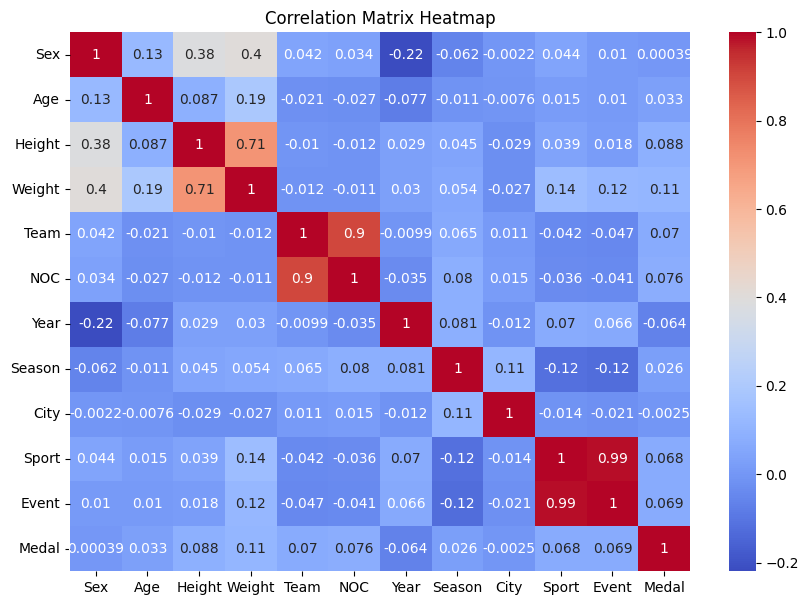

In [ ]:
# Correlation Heatmap
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix Heatmap")
plt.show()

In [ ]:
# Work on models training
# logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
lr=LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9132893496701225
              precision    recall  f1-score   support

           0       0.91      1.00      0.95       969
           1       0.50      0.01      0.02        92

    accuracy                           0.91      1061
   macro avg       0.71      0.50      0.49      1061
weighted avg       0.88      0.91      0.87      1061



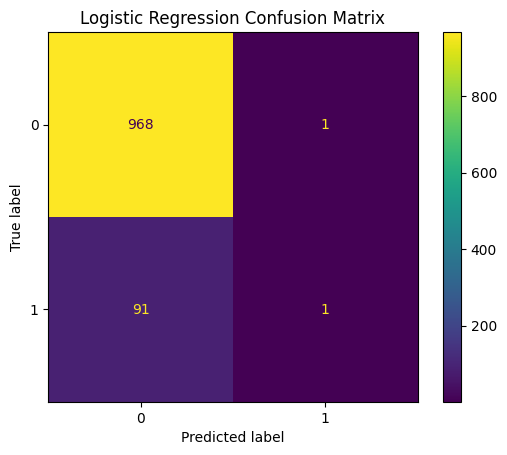

In [ ]:
#logistic regression confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#Confusion matrix of Logistic Regression before applying hyperparameter tuning
cm_lr = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [ ]:
#SVM
from sklearn.svm import SVC
svm = SVC(probability=True)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.9114043355325165
              precision    recall  f1-score   support

           0       0.91      1.00      0.95       969
           1       0.00      0.00      0.00        92

    accuracy                           0.91      1061
   macro avg       0.46      0.50      0.48      1061
weighted avg       0.83      0.91      0.87      1061



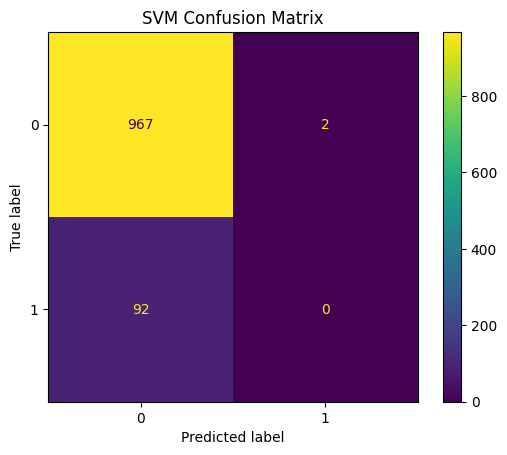

In [ ]:
#Confusion matrix of SVM before applying hyperparameter tuning
cm_svm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm)
disp.plot()
plt.title("SVM Confusion Matrix")
plt.show()

In [ ]:
# KNN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.9000942507068803
              precision    recall  f1-score   support

           0       0.92      0.97      0.95       969
           1       0.32      0.13      0.18        92

    accuracy                           0.90      1061
   macro avg       0.62      0.55      0.57      1061
weighted avg       0.87      0.90      0.88      1061



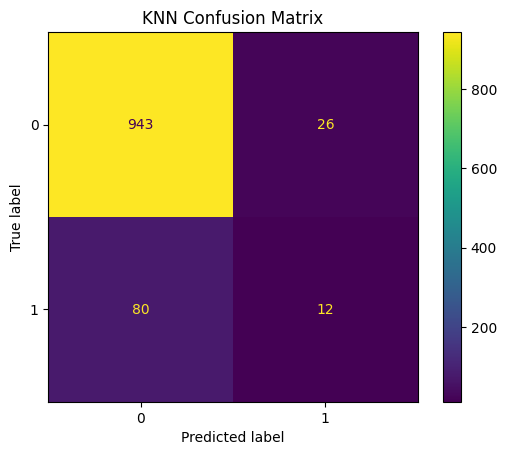

In [ ]:
#Confusion matrix of  KNN before applying hyperparameter tuning
cm_knn = confusion_matrix(y_test, y_pred_knn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn)
disp.plot()
plt.title("KNN Confusion Matrix")
plt.show()

In [ ]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9114043355325165
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       969
           1       0.48      0.28      0.36        92

    accuracy                           0.91      1061
   macro avg       0.71      0.63      0.65      1061
weighted avg       0.90      0.91      0.90      1061



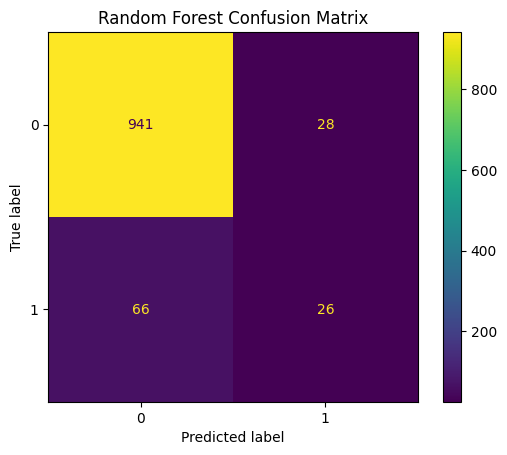

In [ ]:
#Confusion matrix of Random Forest Classifier before applying hyperparameter tuning
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

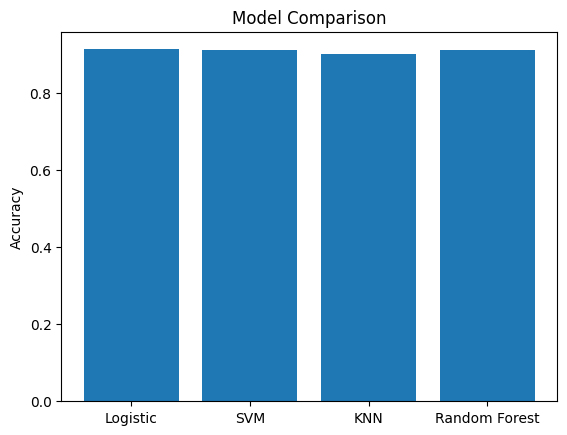

In [ ]:
# Accuracy comparasion
import matplotlib.pyplot as plt

models = ["Logistic", "SVM", "KNN", "Random Forest"]
scores = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_svm),
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_rf)
]

plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
# ROC Curve Before Hyperparameter Tuning
y_prob_lr = lr.predict_proba(X_test)[:,1]
y_prob_svm = svm.predict_proba(X_test)[:,1]
y_prob_knn = knn.predict_proba(X_test)[:,1]
y_prob_rf = rf.predict_proba(X_test)[:,1]

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

auc_lr = auc(fpr_lr, tpr_lr)
auc_svm = auc(fpr_svm, tpr_svm)
auc_knn = auc(fpr_knn, tpr_knn)
auc_rf = auc(fpr_rf, tpr_rf)

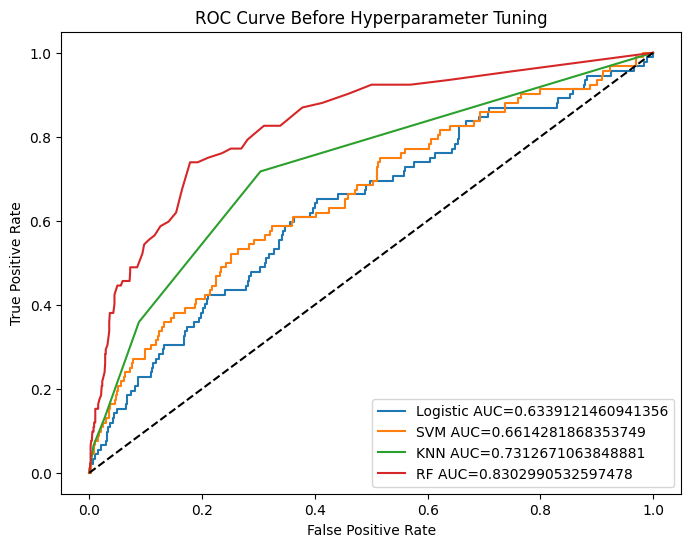

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label="Logistic AUC="+str(auc_lr))
plt.plot(fpr_svm, tpr_svm, label="SVM AUC="+str(auc_svm))
plt.plot(fpr_knn, tpr_knn, label="KNN AUC="+str(auc_knn))
plt.plot(fpr_rf, tpr_rf, label="RF AUC="+str(auc_rf))

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Before Hyperparameter Tuning")
plt.legend()
plt.show()

In [ ]:
# using hyper parameters for tunning
from sklearn.model_selection import GridSearchCV
# Logistic Regression
lr_grid = GridSearchCV(LogisticRegression(), {'C':[0.1,1,10]}, cv=5)
lr_grid.fit(X_train, y_train)

# SVM
svm_grid = GridSearchCV(SVC(), {'C':[0.1,1], 'kernel':['Poly','rbf']}, cv=5)
svm_grid.fit(X_train, y_train)

# KNN
knn_grid = GridSearchCV(KNeighborsClassifier(), {'n_neighbors':[3,5,7]}, cv=5)
knn_grid.fit(X_train, y_train)

# Random Forest
rf_grid = GridSearchCV(RandomForestClassifier(), {'n_estimators':[50,100]}, cv=5)
rf_grid.fit(X_train, y_train)

print("Best LR:", lr_grid.best_params_)
print("Best SVM:", svm_grid.best_params_)
print("Best KNN:", knn_grid.best_params_)
print("Best RF:", rf_grid.best_params_)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
10 fits failed out of a total of 20.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_

Best LR: {'C': 0.1}
Best SVM: {'C': 0.1, 'kernel': 'rbf'}
Best KNN: {'n_neighbors': 7}
Best RF: {'n_estimators': 50}


In [ ]:
best_lr = lr_grid.best_estimator_
best_svm = svm_grid.best_estimator_
best_knn = knn_grid.best_estimator_
best_rf = rf_grid.best_estimator_

In [ ]:
y_pred_lr = best_lr.predict(X_test)
y_pred_svm = best_svm.predict(X_test)
y_pred_knn = best_knn.predict(X_test)
y_pred_rf = best_rf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": y_pred_lr,
    "SVM": y_pred_svm,
    "KNN": y_pred_knn,
    "Random Forest": y_pred_rf
}

for name, pred in models.items():
    print(f"\n{name}")
    print("Best Parameters:",
          lr_grid.best_params_ if name=="Logistic Regression" else
          svm_grid.best_params_ if name=="SVM" else
          knn_grid.best_params_ if name=="KNN" else
          rf_grid.best_params_)

    print("Accuracy :", accuracy_score(y_test, pred))
    print("Precision:", precision_score(y_test, pred))
    print("Recall   :", recall_score(y_test, pred))
    print("F1 Score :", f1_score(y_test, pred))


Logistic Regression
Best Parameters: {'C': 0.1}
Accuracy : 0.9123468426013195
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0

SVM
Best Parameters: {'C': 0.1, 'kernel': 'rbf'}
Accuracy : 0.9132893496701225
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0

KNN
Best Parameters: {'n_neighbors': 7}
Accuracy : 0.9085768143261075
Precision: 0.4
Recall   : 0.10869565217391304
F1 Score : 0.17094017094017094

Random Forest
Best Parameters: {'n_estimators': 50}
Accuracy : 0.9123468426013195
Precision: 0.49056603773584906
Recall   : 0.2826086956521739
F1 Score : 0.3586206896551724


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
svm_grid = GridSearchCV(
    SVC(probability=True),
    {'C': [0.1, 1], 'kernel': ['linear', 'rbf']},
    cv=5
)
svm_grid.fit(X_train, y_train)

best_svm = svm_grid.best_estimator_

In [ ]:
# Logistic Regression
y_prob_lr = best_lr.predict_proba(X_test)[:,1]

# SVM
y_prob_svm = best_svm.predict_proba(X_test)[:,1]

# KNN
y_prob_knn = best_knn.predict_proba(X_test)[:,1]

# Random Forest
y_prob_rf = best_rf.predict_proba(X_test)[:,1]

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

auc_lr = auc(fpr_lr, tpr_lr)
auc_svm = auc(fpr_svm, tpr_svm)
auc_knn = auc(fpr_knn, tpr_knn)
auc_rf = auc(fpr_rf, tpr_rf)

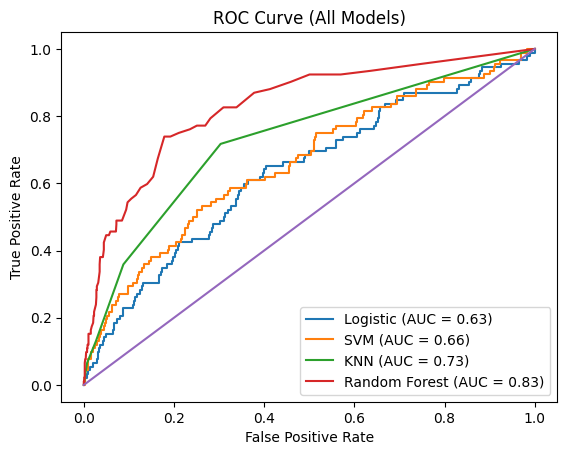

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(fpr_lr, tpr_lr, label=f"Logistic (AUC = {auc_lr:.2f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.2f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC = {auc_knn:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")

# Diagonal line
plt.plot([0,1], [0,1])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (All Models)")
plt.legend()

plt.show()

Logistic Regression
Best Parameters: {'C': 0.1}
Accuracy : 0.9123468426013195
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
Confusion Matrix:
 [[968   1]
 [ 92   0]]


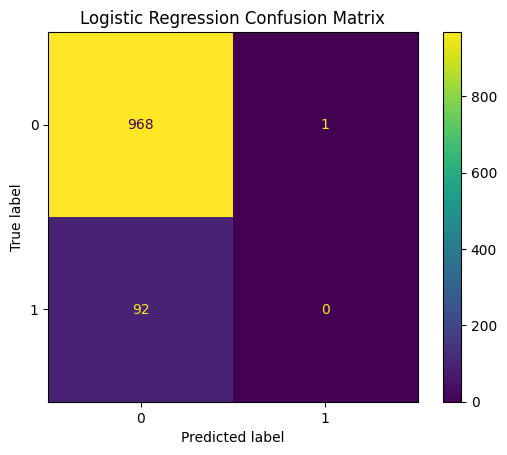

In [ ]:
best_lr = lr_grid.best_estimator_

y_pred_lr = best_lr.predict(X_test)

print("Logistic Regression")
print("Best Parameters:", lr_grid.best_params_)
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
print("Confusion Matrix:\n", cm_lr)

ConfusionMatrixDisplay(cm_lr).plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

SVM
Best Parameters: {'C': 0.1, 'kernel': 'linear'}
Accuracy : 0.9132893496701225
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
Confusion Matrix:
 [[969   0]
 [ 92   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


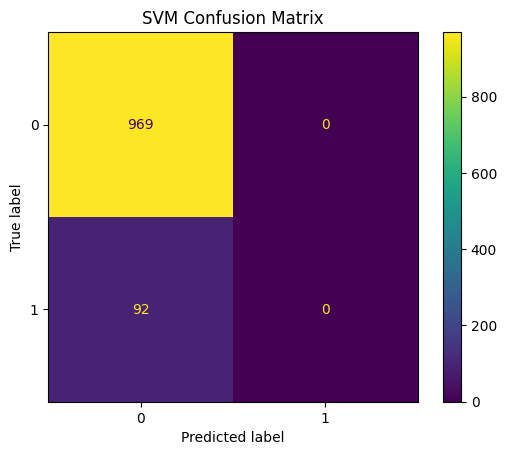

In [ ]:
best_svm = svm_grid.best_estimator_

y_pred_svm = best_svm.predict(X_test)

print("SVM")
print("Best Parameters:", svm_grid.best_params_)
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))

# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
print("Confusion Matrix:\n", cm_svm)

ConfusionMatrixDisplay(cm_svm).plot()
plt.title("SVM Confusion Matrix")
plt.show()

KNN
Best Parameters: {'n_neighbors': 7}
Accuracy : 0.9085768143261075
Precision: 0.4
Recall   : 0.10869565217391304
F1 Score : 0.17094017094017094
Confusion Matrix:
 [[954  15]
 [ 82  10]]


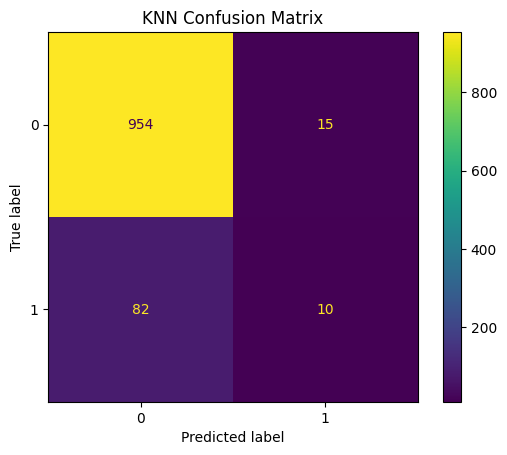

In [ ]:
best_knn = knn_grid.best_estimator_

y_pred_knn = best_knn.predict(X_test)

print("KNN")
print("Best Parameters:", knn_grid.best_params_)
print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall   :", recall_score(y_test, y_pred_knn))
print("F1 Score :", f1_score(y_test, y_pred_knn))

# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
print("Confusion Matrix:\n", cm_knn)

ConfusionMatrixDisplay(cm_knn).plot()
plt.title("KNN Confusion Matrix")
plt.show()

Random Forest
Best Parameters: {'n_estimators': 50}
Accuracy : 0.9123468426013195
Precision: 0.49056603773584906
Recall   : 0.2826086956521739
F1 Score : 0.3586206896551724
Confusion Matrix:
 [[942  27]
 [ 66  26]]


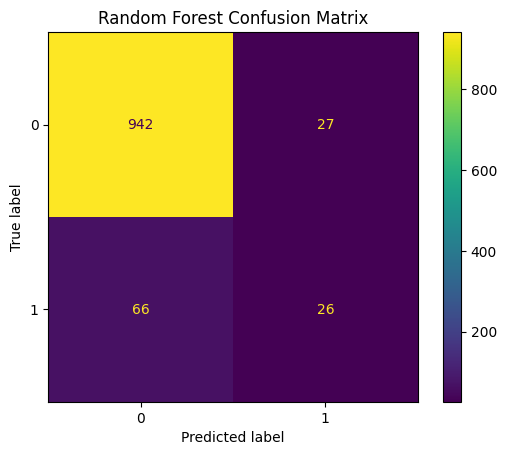

In [ ]:
best_rf = rf_grid.best_estimator_

y_pred_rf = best_rf.predict(X_test)

print("Random Forest")
print("Best Parameters:", rf_grid.best_params_)
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:\n", cm_rf)

ConfusionMatrixDisplay(cm_rf).plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

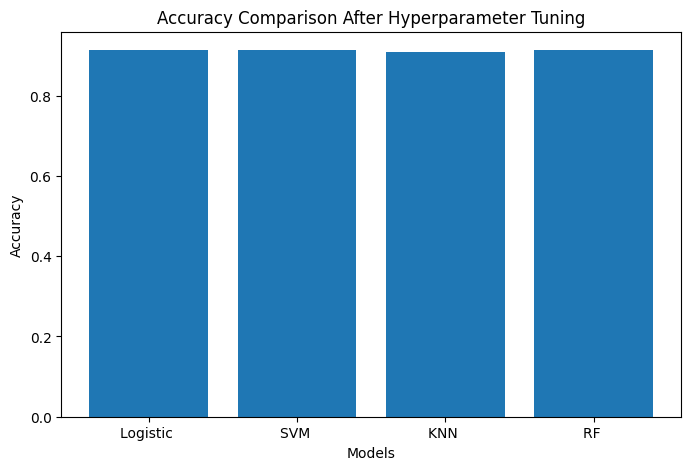

In [ ]:
#Accuracy Comparison After Hyperparameter Tuning
y_pred_lr_tuned = lr_grid.best_estimator_.predict(X_test)
y_pred_svm_tuned = svm_grid.best_estimator_.predict(X_test)
y_pred_knn_tuned = knn_grid.best_estimator_.predict(X_test)
y_pred_rf_tuned = rf_grid.best_estimator_.predict(X_test)

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

models = ["Logistic ", "SVM ", "KNN ", "RF "]

scores = [
    accuracy_score(y_test, y_pred_lr_tuned),
    accuracy_score(y_test, y_pred_svm_tuned),
    accuracy_score(y_test, y_pred_knn_tuned),
    accuracy_score(y_test, y_pred_rf_tuned)
]

plt.figure(figsize=(8,5))
plt.bar(models, scores)
plt.title("Accuracy Comparison After Hyperparameter Tuning")
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.show()